
# MDPs Hands‑On 01 — FrozenLake (Starter)
by Dr. Oscar Fuentes

This notebook:
- Recaps MDP notation in LaTeX.
- Launches **FrozenLake‑v1** (Gymnasium).
- Shows how to inspect transitions and run a random rollout.



## MDP Refresher (LaTeX)

An MDP is \( $\langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$ \). The **policy evaluation** equation under \( $\pi$ \) is
$
V^\pi(s)=\sum_{a}\pi(a\mid s)\sum_{s'}P(s'\mid s,a)\big[R(s,a,s')+\gamma V^\pi(s')\big].
$
**Policy improvement**: choose actions greedy w.r.t. the current value.


In [5]:

# If needed, install gymnasium toy-text (uncomment next line):
# !pip install gymnasium==0.29.1 gymnasium[toy-text]==0.29.1
import matplotlib.pyplot as plt

import gymnasium as gym
print("Gymnasium version:", gym.__version__)


Gymnasium version: 1.3.0


Initial state: 0
[[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [235 245 249]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]]


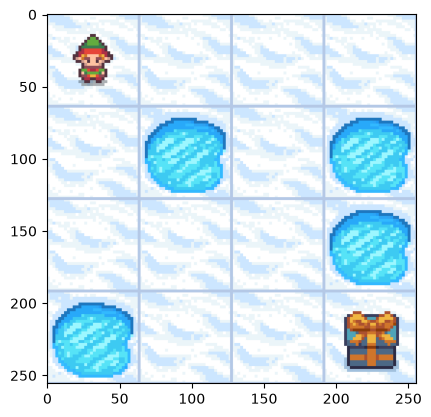

In [6]:

# Launch FrozenLake (text mode for notebooks)
#env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True, render_mode="ansi")
#env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True, render_mode="human")
env = gym.make("FrozenLake-v1", render_mode="rgb_array")
obs, info = env.reset(seed=42)
print("Initial state:", obs)
print(env.render())
plt.imshow(env.render())

In [7]:
env.action_space , env.unwrapped.P

(Discrete(4),
 {0: {0: [(0.33333333333333337, 0, 0, False),
    (0.3333333333333333, 0, 0, False),
    (0.33333333333333337, 4, 0, False)],
   1: [(0.33333333333333337, 0, 0, False),
    (0.3333333333333333, 4, 0, False),
    (0.33333333333333337, 1, 0, False)],
   2: [(0.33333333333333337, 4, 0, False),
    (0.3333333333333333, 1, 0, False),
    (0.33333333333333337, 0, 0, False)],
   3: [(0.33333333333333337, 1, 0, False),
    (0.3333333333333333, 0, 0, False),
    (0.33333333333333337, 0, 0, False)]},
  1: {0: [(0.33333333333333337, 1, 0, False),
    (0.3333333333333333, 0, 0, False),
    (0.33333333333333337, 5, 0, True)],
   1: [(0.33333333333333337, 0, 0, False),
    (0.3333333333333333, 5, 0, True),
    (0.33333333333333337, 2, 0, False)],
   2: [(0.33333333333333337, 5, 0, True),
    (0.3333333333333333, 2, 0, False),
    (0.33333333333333337, 1, 0, False)],
   3: [(0.33333333333333337, 2, 0, False),
    (0.3333333333333333, 1, 0, False),
    (0.33333333333333337, 0, 0, False)]

In [8]:
P = env.unwrapped.P
nS = env.observation_space.n
nA = env.action_space.n
print(f"States: {nS}, Actions: {nA}  (0=LEFT,1=DOWN,2=RIGHT,3=UP)")

s0 = obs
for a in range(nA):
    print(f"\nFrom state {s0}, action {a}:")
    for (prob, s_next, r, done) in P[s0][a]:
        print(f"  prob={prob:.2f} -> s'={s_next}, r={r}, done={done}")


States: 16, Actions: 4  (0=LEFT,1=DOWN,2=RIGHT,3=UP)

From state 0, action 0:
  prob=0.33 -> s'=0, r=0, done=False
  prob=0.33 -> s'=0, r=0, done=False
  prob=0.33 -> s'=4, r=0, done=False

From state 0, action 1:
  prob=0.33 -> s'=0, r=0, done=False
  prob=0.33 -> s'=4, r=0, done=False
  prob=0.33 -> s'=1, r=0, done=False

From state 0, action 2:
  prob=0.33 -> s'=4, r=0, done=False
  prob=0.33 -> s'=1, r=0, done=False
  prob=0.33 -> s'=0, r=0, done=False

From state 0, action 3:
  prob=0.33 -> s'=1, r=0, done=False
  prob=0.33 -> s'=0, r=0, done=False
  prob=0.33 -> s'=0, r=0, done=False


In [9]:

# Random rollout to verify everything is working
def random_rollout(env, max_steps=50, seed=123):
    obs, info = env.reset(seed=seed)
    total_r = 0.0
    for t in range(max_steps):
        a = env.action_space.sample()
        obs, r, terminated, truncated, info = env.step(a)
        total_r += r
        frame = env.render()
        if frame is not None:
            print(frame)
        if terminated or truncated:
            print(f"Episode finished at step {t+1} | total reward = {total_r}")
            break

random_rollout(env)


[[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [235 245 249]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]]
[[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ..

In [10]:
random_rollout(env)


[[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [235 245 249]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]]
[[[180 200 230]
  [180 200 230]
  [180 200 230]
  ...
  [180 200 230]
  [180 200 230]
  [180 200 230]]

 [[180 200 230]
  [204 230 255]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 [[180 200 230]
  [235 245 249]
  [204 230 255]
  ...
  [204 230 255]
  [204 230 255]
  [180 200 230]]

 ...

 [[180 200 230]
  [235 245 249]
  [235 245 249]
  ..

In [11]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array")

## States in FrozenLake

- **Definition:** A *state* in FrozenLake corresponds to one discrete cell in the grid (either Start, Frozen, Hole, or Goal).
- **State space:** For the 4×4 map, we have 16 discrete states (indexed 0–15).
- **State encoding:** The environment encodes each cell as an integer index. You can also map it to row–column coordinates.

Example mapping in 4×4:


In [12]:
# We can peek at the environment's map layout
grid = env.unwrapped.desc  # bytes array of shape (rows, cols)
print("Grid layout (bytes):")
print(grid)

# Convert bytes to strings for readability
grid_str = [[c.decode("utf-8") for c in row] for row in grid]
print("Grid layout (strings):")
for row in grid_str:
    print(row)

# Choose a state index and show its coordinates and type
state_idx = 5  # for example
row = state_idx // env.unwrapped.ncol
col = state_idx % env.unwrapped.ncol
print(f"State {state_idx} corresponds to grid cell ({row},{col}) which is '{grid_str[row][col]}'")


Grid layout (bytes):
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]
Grid layout (strings):
['S', 'F', 'F', 'F']
['F', 'H', 'F', 'H']
['F', 'F', 'F', 'H']
['H', 'F', 'F', 'G']
State 5 corresponds to grid cell (1,1) which is 'H'


## The Markov Property

An environment satisfies the **Markov property** if the probability of transitioning to the next state depends only on the **current state and action**, not on the full history:


$P\bigl(S_{t+1}=s' \mid S_t=s, A_t=a, S_{t-1},A_{t-1},\dots\bigr)
\;=\;
P\bigl(S_{t+1}=s' \mid S_t=s, A_t=a\bigr)
$
- This means the environment’s dynamics are fully captured by \( $(s,a) \to s'$ \) transitions.
- In FrozenLake, given a cell (state) and action, the next-state probabilities are fixed by the environment’s transition matrix `P[s][a]`.


In [13]:
# We can directly inspect the transitions for a given (state, action)
s = 5  # pick a state
a = 2  # action RIGHT
print(f"Transitions from state {s} with action {a}:")
for (prob, s_next, r, done) in P[s][a]:
    print(f"prob={prob:.2f}, next_state={s_next}, reward={r}, done={done}")


Transitions from state 5 with action 2:
prob=1.00, next_state=5, reward=0, done=True


## Rewards in FrozenLake

- **Reward function \(R(s,a,s')\):**  
  - Most transitions give **0** reward.
  - Reaching the **Goal (G)** gives **+1** reward.
  - Falling into a **Hole (H)** gives **0** reward (episode ends).
- **Sparse rewards:** This sparsity makes it harder for algorithms to learn; we rely on value propagation to figure out how close we are to the goal.

Formally:
$
R(s,a,s')=\begin{cases}
+1 & \text{if } s'=\text{Goal}\\[6pt]
0 & \text{otherwise}
\end{cases}
$

Because it’s a tabular MDP, we can directly read all rewards from `env.unwrapped.P`.


In [14]:
# Choose a state index
s = 0  # starting state
print(f"All actions from state {s} and their rewards:")

for a in range(env.action_space.n):
    print(f"\nAction {a}:")
    for (prob, s_next, r, done) in P[s][a]:
        print(f"  prob={prob:.2f} -> next_state={s_next}, reward={r}, done={done}")


All actions from state 0 and their rewards:

Action 0:
  prob=0.33 -> next_state=0, reward=0, done=False
  prob=0.33 -> next_state=0, reward=0, done=False
  prob=0.33 -> next_state=4, reward=0, done=False

Action 1:
  prob=0.33 -> next_state=0, reward=0, done=False
  prob=0.33 -> next_state=4, reward=0, done=False
  prob=0.33 -> next_state=1, reward=0, done=False

Action 2:
  prob=0.33 -> next_state=4, reward=0, done=False
  prob=0.33 -> next_state=1, reward=0, done=False
  prob=0.33 -> next_state=0, reward=0, done=False

Action 3:
  prob=0.33 -> next_state=1, reward=0, done=False
  prob=0.33 -> next_state=0, reward=0, done=False
  prob=0.33 -> next_state=0, reward=0, done=False


In [15]:
P[0][0]

[(0.33333333333333337, 0, 0, False),
 (0.3333333333333333, 0, 0, False),
 (0.33333333333333337, 4, 0, False)]

### Reward Table Snapshot

Because the reward is mostly 0 except at the goal, it’s easy to visualize a **reward matrix**:

- Each cell shows the immediate reward for reaching that cell.
- In FrozenLake, only the Goal cell has +1, everything else is 0.

We can build this directly from the environment’s `desc` (map) to highlight which cells yield positive reward.


In [16]:
import numpy as np

# Build a reward grid (immediate reward on entering each state)
rows, cols = env.unwrapped.desc.shape
reward_grid = np.zeros((rows, cols))

grid = [[c.decode('utf-8') for c in row] for row in env.unwrapped.desc]

for r in range(rows):
    for c in range(cols):
        if grid[r][c] == 'G':
            reward_grid[r, c] = 1.0  # Goal cell +1
        else:
            reward_grid[r, c] = 0.0

print("Reward grid (immediate reward per cell):")
print(reward_grid)


Reward grid (immediate reward per cell):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]]


## Linking Rewards to the Bellman Expectation Equation

Rewards \(R(s,a,s')\) appear inside the Bellman equations:

$
V^\pi(s)=\sum_{a}\pi(a\mid s)\sum_{s'}P(s'\mid s,a)
\bigl[R(s,a,s')+\gamma V^\pi(s')\bigr].
$

- The **immediate reward** is the first part of the bracket.
- The **discounted future value** $\gamma V^\pi(s')$ is the second part.
- Together they determine how attractive a state is under a policy.

In FrozenLake, because rewards are sparse, $V^\pi(s)$ is dominated by the probability of eventually reaching the Goal.


## Bellman Expectation Equation

For any policy $\pi(a\mid s)$, the value function $V^\pi(s)$ satisfies:

$
V^\pi(s)=\sum_{a}\pi(a\mid s)\sum_{s'}P(s'\mid s,a)
\Bigl[R(s,a,s')+\gamma V^\pi(s')\Bigr].
$

- **Left-hand side (LHS):** Value of state \(s\) under \(\pi\).
- **Right-hand side (RHS):** Expected immediate reward plus discounted next-state value.
# - This recursive definition is the heart of MDP solution methods.


In [17]:
# Let's define a simple uniform random policy for demonstration:
nS = env.observation_space.n
nA = env.action_space.n
uniform_policy = np.ones((nS, nA)) / nA  # each action equally likely

gamma = 0.95
state = 0  # starting state

# One-step RHS of Bellman expectation
rhs_val = 0.0
for a in range(nA):
    pi_sa = uniform_policy[state, a]
    for (prob, s_next, r, done) in P[state][a]:
        rhs_val += pi_sa * prob * (r + gamma * 0.0)  # V^\pi(s')=0 for demo
print(f"Expected immediate return from state {state} under uniform policy: {rhs_val:.4f}")


Expected immediate return from state 0 under uniform policy: 0.0000


# Student Example from Slides.

In [18]:
import numpy as np

In [19]:
V= np.zeros(7)

In [20]:
R=np.asarray((-1,-2,-2,-2,10,1,0))

In [21]:
  R

array([-1, -2, -2, -2, 10,  1,  0])

In [22]:
gamma=0.9

In [23]:
A=np.zeros((7,7))
A[0,0]=0.9
A[0,1]=0.1
A[1,0]=0.5
A[1,2]=0.5
A[2,3]=0.8
A[2,6]=0.2
A[3,4]=0.6
A[3,5]=0.4
A[4,6]=1.0
A[4,6]=1.0
A[5,1]= 0.2
A[5,2]=0.4
A[5,3]=0.4
A[6,6]=1.0
A

array([[0.9, 0.1, 0. , 0. , 0. , 0. , 0. ],
       [0.5, 0. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.8, 0. , 0. , 0.2],
       [0. , 0. , 0. , 0. , 0.6, 0.4, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. ],
       [0. , 0.2, 0.4, 0.4, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. ]])

$V(s) = R_s + \gamma \sum_{s' \in \mathcal{S}} P_{s,s'} \, v(s')$

In [24]:
V=np.zeros(7)
Vold=V.copy()


In [25]:

  gamma=1
  for i in range(100):
    for s in range(7):
      Vold=V.copy()
      #V[s] = R[s] + gamma * np.sum(A[s, :] * V)
      V[s] = R[s] + gamma  * A[s,:] @ Vold
  print (f'V old {Vold} , V {V}')

V old [-22.37142399 -12.45245934   1.46604701   4.33201293  10.
   0.82873211   0.        ] , V [-22.37142399 -12.45245934   1.46604701   4.33201293  10.
   0.82873211   0.        ]


In [26]:
V=R + gamma  * A @ Vold
print (np.linalg.norm(V-Vold))
Vold=V.copy()
print (f'V old {Vold} , V {V}')


0.00813516839061804
V old [-22.37952752 -12.45268849   1.46561035   4.33149284  10.
   0.82873211   0.        ] , V [-22.37952752 -12.45268849   1.46561035   4.33149284  10.
   0.82873211   0.        ]
